<a href="https://colab.research.google.com/github/vazquez-agustin/VpC1_Vazquez_Workspace/blob/Pao/TP2_VisionComputadora.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TP2 - Visión por Computadora
## Detector de máximo enfoque en dominio frecuencial

**Referencia:** K. De, V. Masilamani — *"Image Sharpness Measure for Blurred Images in Frequency Domain"*, Procedia Engineering, 2013.

**Objetivo:** Implementar un detector de máximo enfoque sobre el video `focus_video.mov` aplicando la métrica espectral propuesta en el paper.

### Experimento 1: Medición sobre todo el frame

In [61]:
# ── Verificar que el video existe en el directorio de trabajo ─────────────────
import os

VIDEO_NAME = 'focus_video.mov'
VIDEO_PATH = os.path.join(os.getcwd(), VIDEO_NAME)

if os.path.isfile(VIDEO_PATH):
    print(f'✅ Video encontrado: {VIDEO_PATH}')
else:
    raise FileNotFoundError(
        f'⚠️  No se encontró {VIDEO_NAME} en el directorio de trabajo.\n'
        f'   Asegurate de que el archivo esté en la misma carpeta que este notebook.'
    )

✅ Video encontrado: c:\Users\agust\VpC1_Vazquez_Workspace\Trabajo_Practico_2\focus_video.mov


In [62]:
"""
Experimento 1 - Medición de enfoque sobre todo el frame
Métrica: FM (Focus Measure) en dominio frecuencial (De & Masilamani, 2013)
"""

import os, sys, subprocess

# Instalar dependencias si es necesario
def install(pkg):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

try:
    import cv2
except ImportError:
    install("opencv-python-headless")
    import cv2

import numpy as np
import matplotlib.pyplot as plt

### Métrica de enfoque espectral (FM)

El algoritmo propuesto por De & Masilamani calcula la nitidez de una imagen en el dominio frecuencial:

1. Convertir la imagen a escala de grises
2. Calcular la DFT 2D y centrar el espectro (fftshift)
3. Obtener la magnitud del espectro: $|F(u,v)|$
4. Definir un umbral: $Th = \frac{\max(|F|)}{1000}$
5. Contar la cantidad de píxeles cuya magnitud supera el umbral
6. Calcular: $FM = \frac{\text{count}}{M \times N}$

Donde $M \times N$ es el tamaño total de la imagen. Valores más altos de FM indican mayor nitidez.

In [63]:
def focus_measure_spectral(image: np.ndarray) -> float:
    """
    Calcula la métrica de enfoque espectral FM (De & Masilamani, 2013).

    Parámetros:
        image: imagen en escala de grises (2D numpy array)

    Retorna:
        FM: valor de la métrica de enfoque (float entre 0 y 1)
    """
    # 1. DFT 2D
    f_transform = np.fft.fft2(image.astype(np.float64))
    # 2. Centrar el espectro
    f_shifted = np.fft.fftshift(f_transform)
    # 3. Magnitud del espectro
    magnitude = np.abs(f_shifted)
    # 4. Umbral
    max_val = np.max(magnitude)
    threshold = max_val / 1000.0
    # 5. Contar píxeles por encima del umbral
    count = np.sum(magnitude > threshold)
    # 6. FM
    M, N = image.shape
    fm = count / (M * N)
    return fm

### Procesamiento del video

Se recorre cada frame del video, se convierte a escala de grises y se calcula la métrica FM sobre el frame completo.

In [64]:
# Ruta al video
VIDEO_PATH = os.path.join(os.getcwd(), "focus_video.mov")
OUTPUT_DIR = os.path.join(os.getcwd(), "focus_curves")
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Abrir el video
cap = cv2.VideoCapture(VIDEO_PATH)
if not cap.isOpened():
    raise FileNotFoundError(f"No se pudo abrir el video: {VIDEO_PATH}")

total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
fps = cap.get(cv2.CAP_PROP_FPS)
print(f"Frames totales: {total_frames}, FPS: {fps:.2f}")

# Calcular FM para cada frame
fm_values = []
frame_idx = 0

while True:
    ret, frame = cap.read()
    if not ret:
        break
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    fm = focus_measure_spectral(gray)
    fm_values.append(fm)
    frame_idx += 1
    if frame_idx % 25 == 0:
        print(f"  Frame {frame_idx}/{total_frames} — FM = {fm:.4f}")

cap.release()
fm_values = np.array(fm_values)
print(f"\nProcesados {len(fm_values)} frames.")

Frames totales: 171, FPS: 29.97
  Frame 25/171 — FM = 0.0070
  Frame 50/171 — FM = 0.0121
  Frame 75/171 — FM = 0.0237
  Frame 100/171 — FM = 0.0272
  Frame 125/171 — FM = 0.0167
  Frame 150/171 — FM = 0.0073

Procesados 171 frames.


### Detección automática del punto de máximo enfoque

Se identifica automáticamente el frame con el valor máximo de FM.

In [65]:
# Detectar el frame de máximo enfoque
best_frame_idx = np.argmax(fm_values)
best_fm = fm_values[best_frame_idx]

print(f"Máximo enfoque detectado en frame #{best_frame_idx} con FM = {best_fm:.4f}")

Máximo enfoque detectado en frame #109 con FM = 0.0286


### Curva de evolución de la métrica FM (frame completo)

Gráfico que muestra la evolución de la métrica FM a lo largo de todos los frames del video, marcando el punto de máximo enfoque detectado.

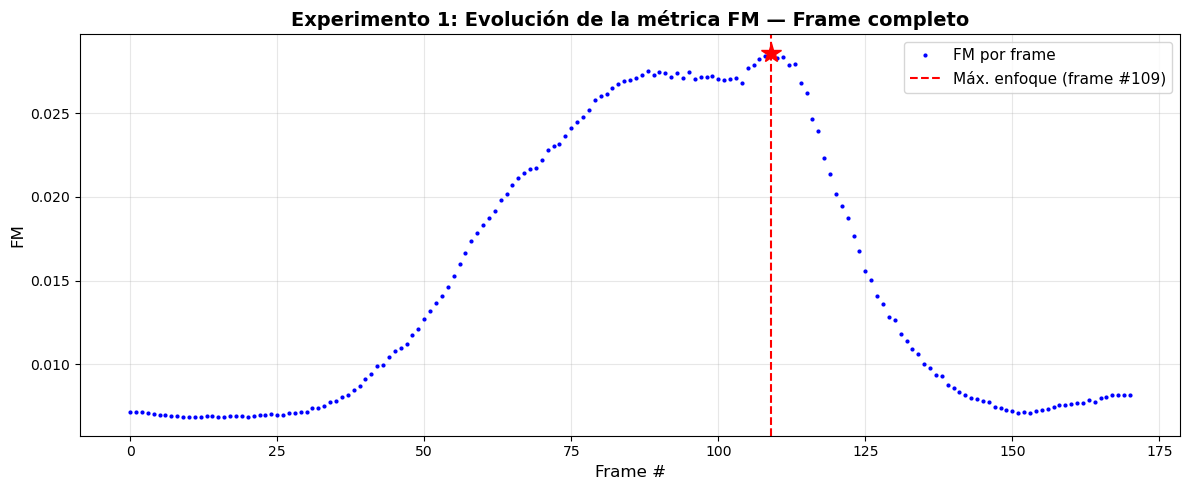

In [66]:
# Graficar la evolución de FM frame a frame
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(range(len(fm_values)), fm_values, "b.", markersize=4, label="FM por frame")
ax.axvline(x=best_frame_idx, color="r", linestyle="--", linewidth=1.5,
           label=f"Máx. enfoque (frame #{best_frame_idx})")
ax.plot(best_frame_idx, best_fm, "r*", markersize=15, zorder=5)

ax.set_xlabel("Frame #", fontsize=12)
ax.set_ylabel("FM", fontsize=12)
ax.set_title("Experimento 1: Evolución de la métrica FM — Frame completo", fontsize=14, fontweight="bold")
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "exp1_fm_full_frame.png"), dpi=150, bbox_inches="tight")
plt.show()

### Visualización del frame de máximo enfoque

Se muestra el frame detectado como el de máximo enfoque junto con su espectro de frecuencias.

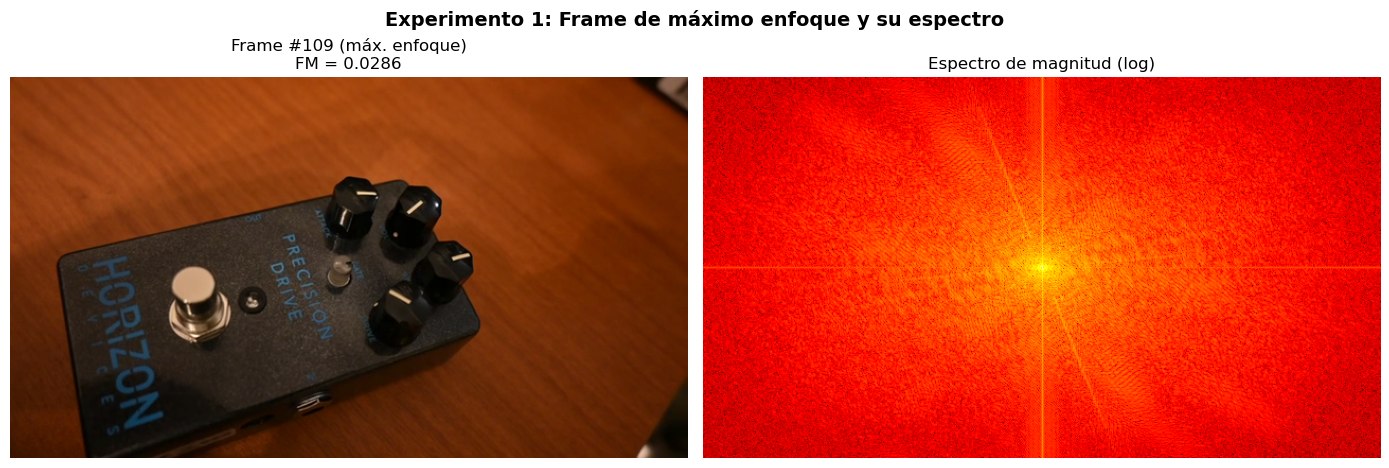

In [67]:
# Extraer el frame de máximo enfoque para visualización
MATRIX_DIR = os.path.join(os.getcwd(), "focus_matrix")
os.makedirs(MATRIX_DIR, exist_ok=True)

cap = cv2.VideoCapture(VIDEO_PATH)
cap.set(cv2.CAP_PROP_POS_FRAMES, best_frame_idx)
ret, best_frame = cap.read()
cap.release()

if ret:
    best_gray = cv2.cvtColor(best_frame, cv2.COLOR_BGR2GRAY)

    # Espectro de frecuencias del frame de máximo enfoque
    f_transform = np.fft.fft2(best_gray.astype(np.float64))
    f_shifted = np.fft.fftshift(f_transform)
    magnitude_spectrum = 20 * np.log10(np.abs(f_shifted) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].imshow(cv2.cvtColor(best_frame, cv2.COLOR_BGR2RGB))
    axes[0].set_title(f"Frame #{best_frame_idx} (máx. enfoque)\nFM = {best_fm:.4f}", fontsize=12)
    axes[0].axis("off")

    axes[1].imshow(magnitude_spectrum, cmap="hot")
    axes[1].set_title("Espectro de magnitud (log)", fontsize=12)
    axes[1].axis("off")

    plt.suptitle("Experimento 1: Frame de máximo enfoque y su espectro", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.savefig(os.path.join(MATRIX_DIR, "exp1_best_frame_spectrum.png"), dpi=150, bbox_inches="tight")
    plt.show()

---

## Experimento 2: Medición sobre una ROI central

En el Experimento 1 la métrica FM se calculó sobre el **frame completo**, lo que incluye fondos, bordes y zonas periféricas que generalmente no son el objeto de interés.

En este punto 2 del trabajo vamos a definir una **Región de Interés (ROI)** cuadrada centrada en el frame, y calculando FM **únicamente sobre esa región**. Evaluaremos si restringir el análisis al centro mejora la detección del punto de máximo enfoque respecto al método del frame completo.

### Definición geométrica de la ROI

Se elige una ROI cuadrada que ocupe el **10% del área total** del frame. Para un frame de dimensiones $H \times W$, el lado $L$ se obtiene despejando de:

$$L^2 = 0.10 \times H \times W \implies L = \sqrt{0.10 \times H \times W}$$

La ROI queda centrada en $(H/2,\; W/2)$ con márgenes $\pm L/2$ en cada eje. Las coordenadas se cliptean para garantizar que el recorte no se salga de los límites del frame.

Con relación al punto anterior **Experimento 1**, la función `focus_measure_spectral` se reutiliza **sin modificaciones**. La única diferencia es que en lugar de pasarle el frame completo, se le pasa el recorte de la ROI. Esto significa que la DFT, el umbral y el conteo de píxeles se calculan sobre un área mucho menor, lo que puede hacer a la métrica más sensible a los cambios de enfoque en el centro de la escena.

In [68]:
# ── Paso 1: definir la proporción de área para la ROI ────────────────────────
# Se puede cambiar a 0.05 para usar el 5% del área en lugar del 10%
ROI_AREA_RATIO = 0.10


def get_central_roi(frame_gray: np.ndarray, area_ratio: float = 0.10):
    """
    Extrae una ROI cuadrada centrada en el frame.

    El lado L se calcula como: L = sqrt(area_ratio * H * W)
    de forma que L² ≈ area_ratio * H * W (ROI ocupa el porcentaje pedido).

    Parámetros:
        frame_gray : imagen en escala de grises (H x W)
        area_ratio : fracción del área total (0.10 = 10%, 0.05 = 5%)

    Retorna:
        roi           : subimagen recortada (numpy array)
        (r1,c1,r2,c2) : coordenadas del recorte en píxeles del frame original
    """
    H, W = frame_gray.shape

    # Calcular el lado del cuadrado: L² = area_ratio * H * W
    L = int(np.sqrt(area_ratio * H * W))

    # Encontrar el centro geométrico del frame
    cy, cx = H // 2, W // 2

    # Calcular los bordes del recorte centrado en (cy, cx)
    # Se usa max/min para no salirnos de los límites del frame
    r1 = max(0, cy - L // 2)   # fila superior
    r2 = min(H, r1 + L)        # fila inferior
    c1 = max(0, cx - L // 2)   # columna izquierda
    c2 = min(W, c1 + L)        # columna derecha

    # Devolver el recorte y sus coordenadas (esto nos ayuda para dibujarlo luego)
    return frame_gray[r1:r2, c1:c2], (r1, c1, r2, c2)


# ── Paso 2: recorrer el video y calcular FM sobre la ROI de cada frame ────────
cap = cv2.VideoCapture(VIDEO_PATH)
if not cap.isOpened():
    raise FileNotFoundError(f'No se pudo abrir el video: {VIDEO_PATH}')

total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
fps          = cap.get(cv2.CAP_PROP_FPS)

fm_roi_values = []   # acumula el FM de la ROI para cada frame
roi_coords    = None # las coordenadas de la ROI son fijas (mismo tamaño de frame siempre)
frame_idx     = 0

while True:
    ret, frame = cap.read()    # leer el siguiente frame
    if not ret:                 # fin del video
        break

    # Convertir a escala de grises (FM opera sobre intensidades)
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    # Recortar la ROI central del frame actual
    roi, coords = get_central_roi(gray, ROI_AREA_RATIO)

    # En el primer frame: mostrar dimensiones para verificar que la ROI es correcta
    if roi_coords is None:
        roi_coords = coords
        H, W   = gray.shape
        L_side = coords[2] - coords[0]
        print(f'Frame size    : {W} x {H} px  ({W*H:,} px totales)')
        print(f'ROI size      : {L_side} x {L_side} px  ({L_side**2:,} px = {L_side**2/(W*H)*100:.1f}% del frame)')
        print(f'ROI coords    : filas [{coords[0]}:{coords[2]}], cols [{coords[1]}:{coords[3]}]')
        print(f'Frames totales: {total_frames}  |  FPS: {fps:.2f}\n')

    # Calcular FM únicamente sobre los píxeles de la ROI
    # La función es exactamente la misma del experimento 1
    fm = focus_measure_spectral(roi)
    fm_roi_values.append(fm)
    frame_idx += 1
    if frame_idx % 25 == 0:
        print(f'  Frame {frame_idx}/{total_frames} — FM_ROI = {fm:.4f}')

cap.release()
fm_roi_values = np.array(fm_roi_values)
print(f'\nProcesados {len(fm_roi_values)} frames (ROI).')

Frame size    : 640 x 360 px  (230,400 px totales)
ROI size      : 151 x 151 px  (22,801 px = 9.9% del frame)
ROI coords    : filas [105:256], cols [245:396]
Frames totales: 171  |  FPS: 29.97

  Frame 25/171 — FM_ROI = 0.0371
  Frame 50/171 — FM_ROI = 0.0614
  Frame 75/171 — FM_ROI = 0.1503
  Frame 100/171 — FM_ROI = 0.3192
  Frame 125/171 — FM_ROI = 0.0978
  Frame 150/171 — FM_ROI = 0.0486

Procesados 171 frames (ROI).


### Detección automática del punto de máximo enfoque (ROI)

Con el array `fm_roi_values` completo, se busca el frame con el valor más alto de FM calculado sobre la ROI. Se compara el resultado con el frame detectado en el Experimento 1 para evaluar si ambos métodos convergen al mismo punto de enfoque óptimo o si la restricción a la ROI desplaza la detección.

In [69]:
# np.argmax devuelve el índice del valor máximo en fm_roi_values
# Ese índice es el número de frame con mayor nitidez según la ROI
best_frame_roi_idx = int(np.argmax(fm_roi_values))
best_fm_roi        = fm_roi_values[best_frame_roi_idx]

print(f'Máximo enfoque (ROI)           → frame #{best_frame_roi_idx:>4}  |  FM_ROI = {best_fm_roi:.4f}')
print(f'Máximo enfoque (frame completo) → frame #{best_frame_idx:>4}  |  FM     = {best_fm:.4f}')

# Comparar si ambos métodos detectaron el mismo frame óptimo
if best_frame_roi_idx == best_frame_idx:
    print('\n✅ Ambos métodos coinciden en el mismo frame de máximo enfoque.')
else:
    print(f'\n Los métodos difieren:')
    print(f'   Frame completo → #{best_frame_idx}')
    print(f'   ROI central    → #{best_frame_roi_idx}')
    print(f'   Diferencia     : {abs(best_frame_roi_idx - best_frame_idx)} frames')

Máximo enfoque (ROI)           → frame # 111  |  FM_ROI = 0.3474
Máximo enfoque (frame completo) → frame # 109  |  FM     = 0.0286

 Los métodos difieren:
   Frame completo → #109
   ROI central    → #111
   Diferencia     : 2 frames


### Curva comparativa FM — Frame completo vs ROI central

Se grafican ambas curvas en el mismo eje para comparar visualmente la evolución de la métrica de enfoque a lo largo del video. El gráfico tiene **dos paneles**:

- **Panel superior:** curvas superpuestas. La línea azul continua corresponde al Experimento 1 (frame completo) y la línea naranja punteada al Experimento 2 (ROI central). Las líneas verticales punteadas marcan el frame de máximo enfoque detectado por cada método; las estrellas señalan el punto exacto del máximo.

- **Panel inferior:** diferencia frame a frame `FM_ROI − FM_frame_completo`. Cuando la diferencia es positiva (zona naranja), la ROI fue más sensible al enfoque que el frame completo en ese frame; cuando es negativa (zona azul), ocurre lo contrario. Este panel ayuda a identificar en qué segmentos del video ambos métodos se comportan de forma distinta.

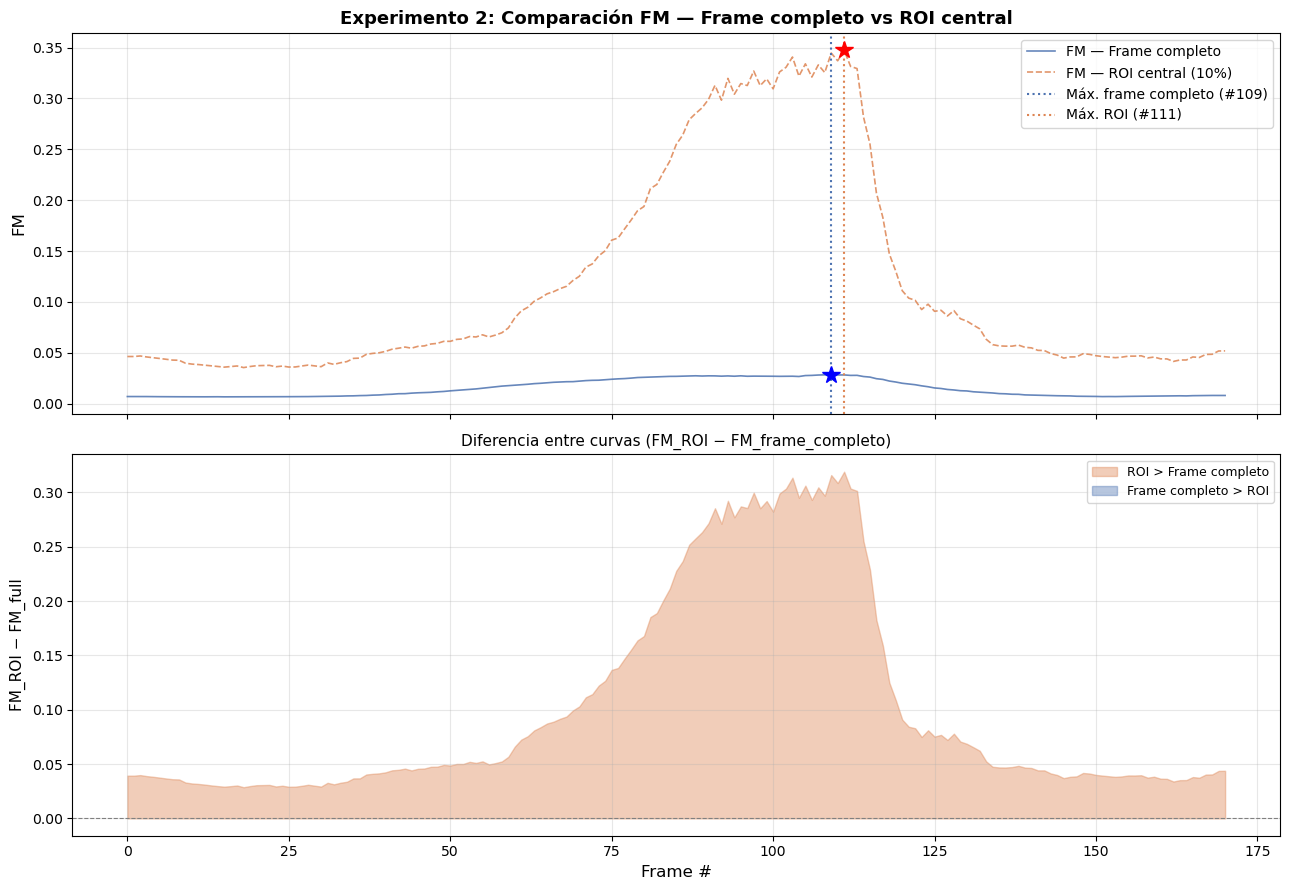


Resumen comparativo:
  Frame completo → Máx. enfoque en frame # 109  |  FM = 0.0286
  ROI central    → Máx. enfoque en frame # 111  |  FM = 0.3474


In [70]:
# ── Graficar la comparación entre ambas curvas FM ────────────────────────────
frames = range(len(fm_values))

# Dos paneles apilados verticalmente con eje X compartido
fig, axes = plt.subplots(2, 1, figsize=(13, 9), sharex=True)

# ── Panel superior: curvas superpuestas ──────────────────────────────────────
ax = axes[0]

# Curva Experimento 1: FM sobre frame completo
ax.plot(frames, fm_values,     color='#4C72B0', linewidth=1.2,
        label='FM — Frame completo', alpha=0.85)

# Curva Experimento 2: FM sobre ROI central
ax.plot(frames, fm_roi_values, color='#DD8452', linewidth=1.2,
        linestyle='--', label=f'FM — ROI central ({int(ROI_AREA_RATIO*100)}%)', alpha=0.85)

# Líneas verticales marcando el frame óptimo de cada método
ax.axvline(best_frame_idx,     color='#4C72B0', linestyle=':',  linewidth=1.5,
           label=f'Máx. frame completo (#{best_frame_idx})')
ax.axvline(best_frame_roi_idx, color='#DD8452', linestyle=':',  linewidth=1.5,
           label=f'Máx. ROI (#{best_frame_roi_idx})')

# Estrellas sobre el punto de máximo de cada curva
ax.plot(best_frame_idx,     fm_values[best_frame_idx],         'b*', markersize=13, zorder=5)
ax.plot(best_frame_roi_idx, fm_roi_values[best_frame_roi_idx], 'r*', markersize=13, zorder=5)
ax.set_ylabel('FM', fontsize=12)
ax.set_title('Experimento 2: Comparación FM — Frame completo vs ROI central',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# ── Panel inferior: diferencia FM_ROI − FM_frame_completo ────────────────────
# Valores positivos: la ROI detectó más enfoque que el frame completo
# Valores negativos: el frame completo detectó más enfoque que la ROI
ax2   = axes[1]
diff  = fm_roi_values - fm_values

# Zona naranja donde ROI > frame completo
ax2.fill_between(frames, diff, 0,
                 where=(diff >= 0), color='#DD8452', alpha=0.4, label='ROI > Frame completo')
# Zona azul donde frame completo > ROI
ax2.fill_between(frames, diff, 0,
                 where=(diff <  0), color='#4C72B0', alpha=0.4, label='Frame completo > ROI')

ax2.axhline(0, color='gray', linewidth=0.8, linestyle='--')   # línea de referencia cero
ax2.set_xlabel('Frame #', fontsize=12)
ax2.set_ylabel('FM_ROI − FM_full', fontsize=11)
ax2.set_title('Diferencia entre curvas (FM_ROI − FM_frame_completo)', fontsize=11)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'exp2_fm_roi_vs_full.png'), dpi=150, bbox_inches='tight')
plt.show()

# Resumen numérico final
print(f'\nResumen comparativo:')
print(f'  Frame completo → Máx. enfoque en frame #{best_frame_idx:>4}  |  FM = {best_fm:.4f}')
print(f'  ROI central    → Máx. enfoque en frame #{best_frame_roi_idx:>4}  |  FM = {best_fm_roi:.4f}')

La diferencia FM_ROI − FM_full es siempre positiva (zona naranja pura, sin ninguna zona azul). Esto significa que en absolutamente ningún frame el método de frame completo superó a la ROI. La ROI fue consistentemente más informativa durante todo el video.

### Visualización del frame de máximo enfoque (ROI)

Se extrae el frame identificado como óptimo por el método ROI y se presenta en tres paneles:

1. **Frame completo con ROI destacada:** el recuadro verde muestra exactamente qué región del frame fue analizada. Permite verificar visualmente que la ROI está bien centrada y que el sujeto principal está dentro de ella.
2. **ROI recortada:** la subimagen que recibió `focus_measure_spectral`. Se puede apreciar el nivel de detalle y nitidez de la zona central en el frame de máximo enfoque.
3. **Espectro de magnitud de la ROI (log):** la transformada de Fourier de la ROI en escala logarítmica. En un frame nítido se espera ver energía distribuida hacia las zonas alejadas del centro del espectro, indicando presencia de componentes de alta frecuencia.

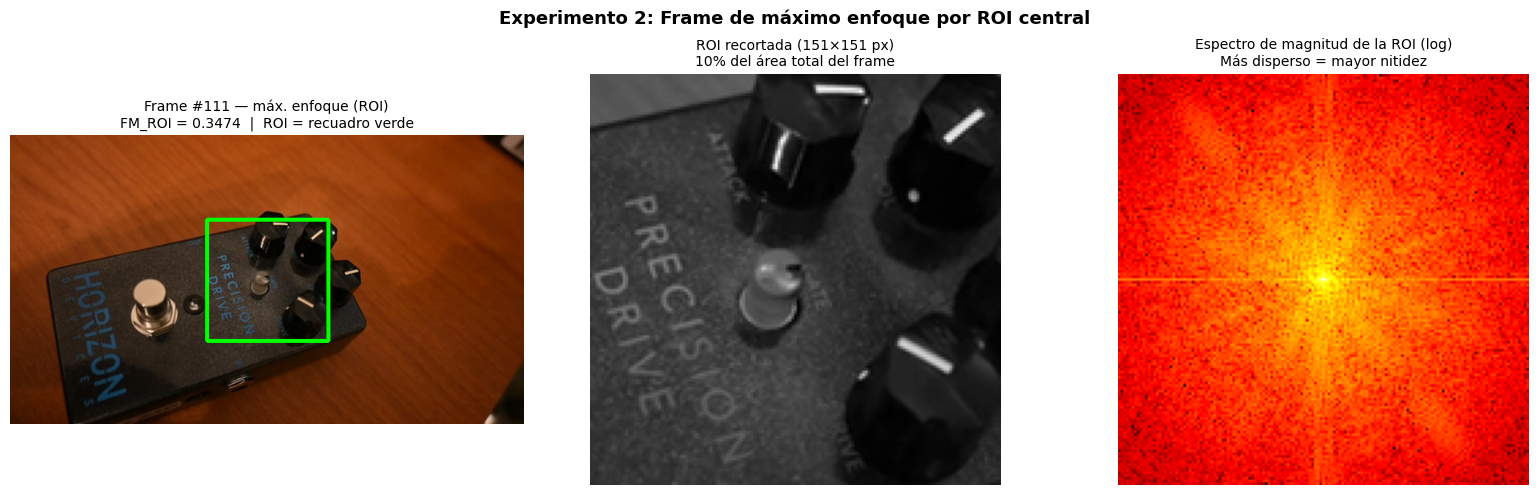

In [71]:
# Posicionarse en el frame de máximo enfoque según la ROI y leerlo
cap = cv2.VideoCapture(VIDEO_PATH)
cap.set(cv2.CAP_PROP_POS_FRAMES, best_frame_roi_idx)   # saltar directo al frame óptimo
ret, best_frame_roi = cap.read()
cap.release()

if ret:
    # Convertir a escala de grises para el cálculo del espectro
    best_gray_roi = cv2.cvtColor(best_frame_roi, cv2.COLOR_BGR2GRAY)

    # Obtener la ROI y sus coordenadas (para dibujar el recuadro)
    roi_patch, (r1, c1, r2, c2) = get_central_roi(best_gray_roi, ROI_AREA_RATIO)

    # Dibujar el rectángulo verde sobre una copia del frame original
    # Esto no modifica best_frame_roi, solo la copia anotada
    frame_annotated = best_frame_roi.copy()
    cv2.rectangle(frame_annotated, (c1, r1), (c2, r2), (0, 255, 0), 3)

    # Calcular el espectro de magnitud de la ROI en escala logarítmica
    # Se aplica la misma pipeline que en focus_measure_spectral
    f_roi   = np.fft.fft2(roi_patch.astype(np.float64))  # DFT 2D de la ROI
    f_shift = np.fft.fftshift(f_roi)                      # centrar espectro
    mag_roi = 20 * np.log10(np.abs(f_shift) + 1)          # magnitud en dB (log)

    # Visualizar en tres paneles
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    # Panel 1: frame completo con ROI marcada en verde
    axes[0].imshow(cv2.cvtColor(frame_annotated, cv2.COLOR_BGR2RGB))
    axes[0].set_title(f'Frame #{best_frame_roi_idx} — máx. enfoque (ROI)\n'
                      f'FM_ROI = {best_fm_roi:.4f}  |  ROI = recuadro verde', fontsize=10)
    axes[0].axis('off')

    # Panel 2: recorte de la ROI — zona efectivamente analizada
    axes[1].imshow(roi_patch, cmap='gray')
    axes[1].set_title(f'ROI recortada ({roi_patch.shape[1]}×{roi_patch.shape[0]} px)\n'
                      f'{int(ROI_AREA_RATIO*100)}% del área total del frame', fontsize=10)
    axes[1].axis('off')

    # Panel 3: espectro de magnitud de la ROI
    # Zonas brillantes alejadas del centro indican alta nitidez
    axes[2].imshow(mag_roi, cmap='hot')
    axes[2].set_title('Espectro de magnitud de la ROI (log)\n'
                      'Más disperso = mayor nitidez', fontsize=10)
    axes[2].axis('off')

    plt.suptitle('Experimento 2: Frame de máximo enfoque por ROI central',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(MATRIX_DIR, 'exp2_best_frame_roi.png'), dpi=150, bbox_inches='tight')
    plt.show()

---

### Matriz de enfoque superpuesta al frame

Para visualizar la **distribución espacial del enfoque** se divide el frame en una grilla de bloques y se calcula la métrica FM en cada uno de ellos. El resultado es una matriz (heatmap) que se superpone al frame original con transparencia, permitiendo identificar de un vistazo qué zonas del frame están más enfocadas.

**Procedimiento:**
1. Se toma el frame de máximo enfoque detectado en el Experimento 1.
2. Se divide en bloques de tamaño $B \times B$ píxeles.
3. Se calcula `focus_measure_spectral` sobre cada bloque.
4. Se construye una matriz de FM del mismo tamaño que el frame, asignando a cada píxel el valor FM del bloque al que pertenece.
5. Se superpone el heatmap al frame original usando un colormap con transparencia.

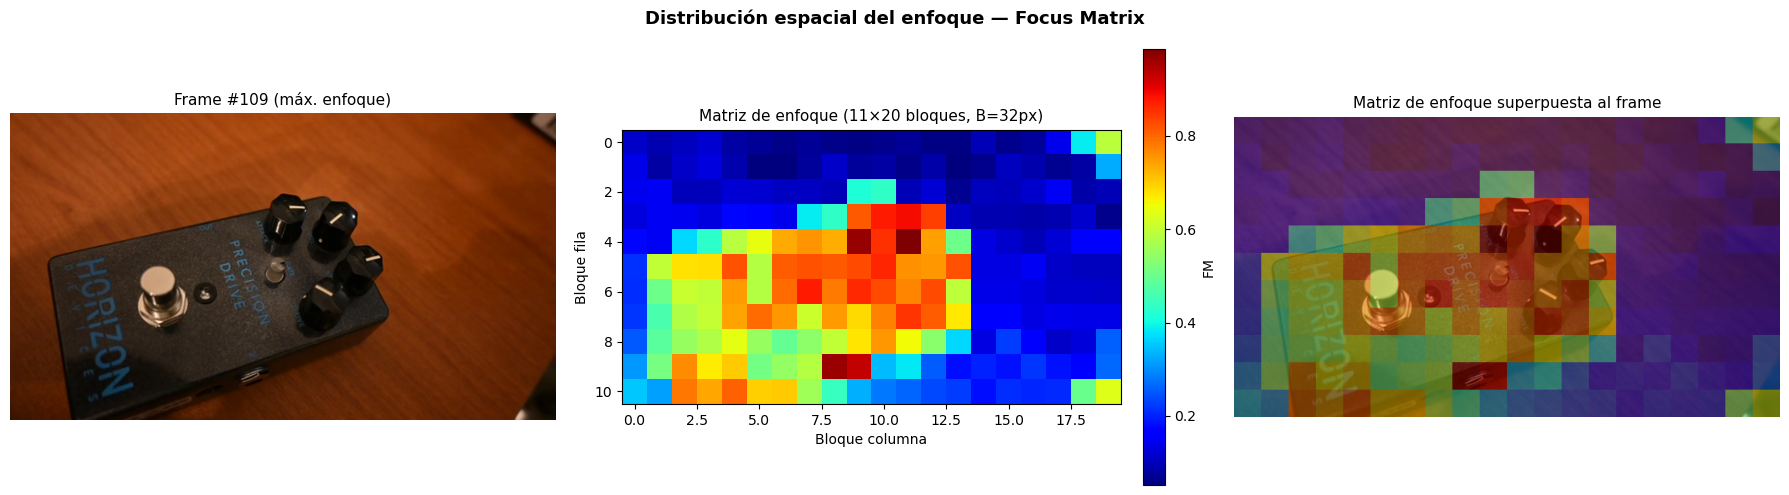

Bloques: 11 filas × 20 cols = 220 bloques de 32×32 px
FM mín. bloque: 0.0518  |  FM máx. bloque: 0.9873


In [72]:
# ── Matriz de enfoque superpuesta al frame ────────────────────────────────────
BLOCK_SIZE = 32  # tamaño del bloque en píxeles (B x B)

# Leer el frame de máximo enfoque (Experimento 1)
cap = cv2.VideoCapture(VIDEO_PATH)
cap.set(cv2.CAP_PROP_POS_FRAMES, best_frame_idx)
ret, frame_best = cap.read()
cap.release()

if ret:
    gray_best = cv2.cvtColor(frame_best, cv2.COLOR_BGR2GRAY)
    H, W = gray_best.shape

    # Cantidad de bloques en cada eje
    n_rows = H // BLOCK_SIZE
    n_cols = W // BLOCK_SIZE

    # Calcular FM por bloque
    fm_matrix = np.zeros((n_rows, n_cols), dtype=np.float64)
    for i in range(n_rows):
        for j in range(n_cols):
            block = gray_best[i * BLOCK_SIZE:(i + 1) * BLOCK_SIZE,
                              j * BLOCK_SIZE:(j + 1) * BLOCK_SIZE]
            fm_matrix[i, j] = focus_measure_spectral(block)

    # Expandir la matriz al tamaño del frame (cada bloque ocupa B×B píxeles)
    fm_heatmap = np.kron(fm_matrix, np.ones((BLOCK_SIZE, BLOCK_SIZE)))
    # Recortar al tamaño original por si hay píxeles sobrantes
    fm_heatmap = fm_heatmap[:H, :W]

    # Visualización: frame original + heatmap superpuesto
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Panel 1: frame original
    frame_rgb = cv2.cvtColor(frame_best, cv2.COLOR_BGR2RGB)
    axes[0].imshow(frame_rgb)
    axes[0].set_title(f'Frame #{best_frame_idx} (máx. enfoque)', fontsize=11)
    axes[0].axis('off')

    # Panel 2: heatmap de enfoque solo
    im = axes[1].imshow(fm_matrix, cmap='jet', interpolation='nearest')
    axes[1].set_title(f'Matriz de enfoque ({n_rows}×{n_cols} bloques, B={BLOCK_SIZE}px)',
                      fontsize=11)
    axes[1].set_xlabel('Bloque columna')
    axes[1].set_ylabel('Bloque fila')
    plt.colorbar(im, ax=axes[1], label='FM', fraction=0.046, pad=0.04)

    # Panel 3: heatmap superpuesto al frame
    axes[2].imshow(frame_rgb)
    axes[2].imshow(fm_heatmap, cmap='jet', alpha=0.45)
    axes[2].set_title('Matriz de enfoque superpuesta al frame', fontsize=11)
    axes[2].axis('off')

    plt.suptitle('Distribución espacial del enfoque — Focus Matrix',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(MATRIX_DIR, 'focus_matrix_overlay.png'), dpi=150, bbox_inches='tight')
    plt.show()

    print(f'Bloques: {n_rows} filas × {n_cols} cols = {n_rows * n_cols} bloques de {BLOCK_SIZE}×{BLOCK_SIZE} px')
    print(f'FM mín. bloque: {fm_matrix.min():.4f}  |  FM máx. bloque: {fm_matrix.max():.4f}')

El heatmap confirma que el enfoque no es uniforme en el frame: las zonas con mayor FM se concentran sobre el objeto y sus bordes, mientras que el fondo (madera, superficies lisas) mantiene valores bajos. Esta visualización es análoga al *focus peaking* de las cámaras digitales modernas y permite validar espacialmente dónde la métrica espectral detecta nitidez.

---

## Unsharp Masking

El **unsharp masking** es una técnica clásica de realce de bordes que permite expandir perceptualmente la zona de enfoque de una imagen. El procedimiento es:

1. Se genera una versión suavizada (blur) de la imagen original: $G = \text{GaussianBlur}(I)$
2. Se calcula la máscara de detalle: $D = I - G$
3. Se suma la máscara ponderada a la original: $I_{\text{sharp}} = I + \alpha \cdot D$

Donde $\alpha$ controla la intensidad del realce. Valores típicos están entre 1.0 y 3.0.

Se aplica unsharp masking al frame de máximo enfoque y se compara visualmente el resultado, junto con la métrica FM antes y después del procesamiento.

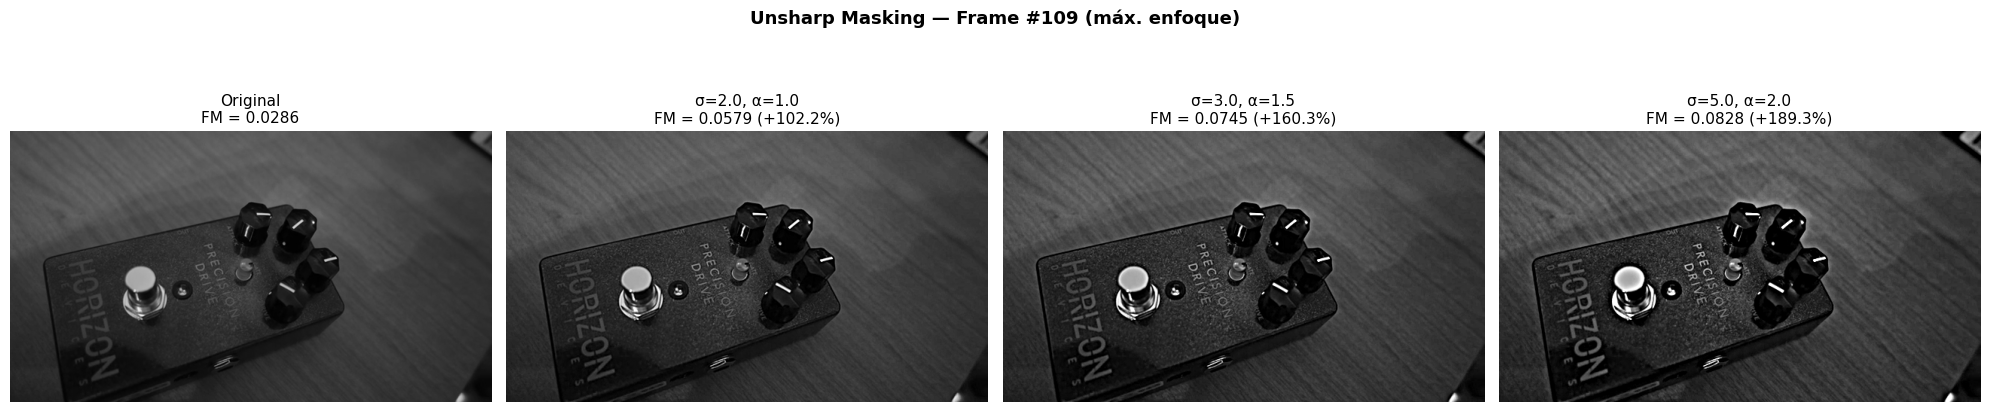

In [73]:
# ── Unsharp Masking ───────────────────────────────────────────────────────────

def unsharp_mask(image: np.ndarray, sigma: float = 3.0, alpha: float = 1.5) -> np.ndarray:
    """
    Aplica unsharp masking a una imagen en escala de grises.

    Parámetros:
        image : imagen en escala de grises (2D numpy array, uint8)
        sigma : desvío estándar del filtro gaussiano
        alpha : factor de realce (intensidad del sharpening)

    Retorna:
        sharpened : imagen realzada (uint8, mismo tamaño que image)
    """
    # Kernel size impar basado en sigma (cubre ~3 sigmas por lado)
    ksize = int(2 * np.ceil(3 * sigma) + 1)
    # 1. Versión suavizada
    blurred = cv2.GaussianBlur(image, (ksize, ksize), sigma)
    # 2. Máscara de detalle
    detail = image.astype(np.float64) - blurred.astype(np.float64)
    # 3. Sumar máscara ponderada
    sharpened = image.astype(np.float64) + alpha * detail
    # Clipear a [0, 255] y convertir a uint8
    sharpened = np.clip(sharpened, 0, 255).astype(np.uint8)
    return sharpened


# Leer el frame de máximo enfoque
cap = cv2.VideoCapture(VIDEO_PATH)
cap.set(cv2.CAP_PROP_POS_FRAMES, best_frame_idx)
ret, frame_orig = cap.read()
cap.release()

if ret:
    gray_orig = cv2.cvtColor(frame_orig, cv2.COLOR_BGR2GRAY)

    # FM antes del unsharp masking
    fm_before = focus_measure_spectral(gray_orig)

    # Aplicar unsharp masking con distintos parámetros
    configs = [
        {'sigma': 2.0, 'alpha': 1.0},
        {'sigma': 3.0, 'alpha': 1.5},
        {'sigma': 5.0, 'alpha': 2.0},
    ]

    fig, axes = plt.subplots(1, 1 + len(configs), figsize=(5 * (1 + len(configs)), 5))

    # Panel 1: imagen original
    axes[0].imshow(gray_orig, cmap='gray')
    axes[0].set_title(f'Original\nFM = {fm_before:.4f}', fontsize=11)
    axes[0].axis('off')

    for k, cfg in enumerate(configs):
        sharpened = unsharp_mask(gray_orig, sigma=cfg['sigma'], alpha=cfg['alpha'])
        fm_after = focus_measure_spectral(sharpened)

        axes[k + 1].imshow(sharpened, cmap='gray')
        axes[k + 1].set_title(f'σ={cfg["sigma"]}, α={cfg["alpha"]}\n'
                              f'FM = {fm_after:.4f} ({(fm_after/fm_before - 1)*100:+.1f}%)',
                              fontsize=11)
        axes[k + 1].axis('off')

    plt.suptitle(f'Unsharp Masking — Frame #{best_frame_idx} (máx. enfoque)',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(MATRIX_DIR, 'unsharp_masking_comparison.png'), dpi=150, bbox_inches='tight')
    plt.show()

Se observa que a mayor $\alpha$ y $\sigma$, mayor es el incremento en FM. Sin embargo, configuraciones agresivas (σ=5.0, α=2.0) pueden introducir halos y amplificar ruido. La configuración intermedia (σ=3.0, α=1.5) ofrece un buen compromiso entre realce de bordes y ausencia de artefactos visibles.

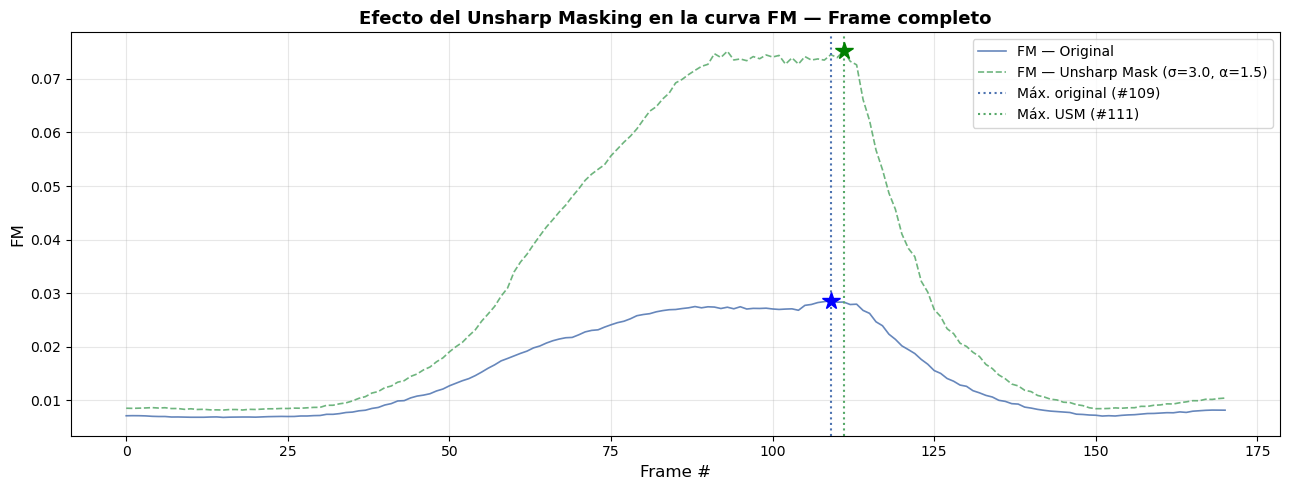

Máx. enfoque original    → frame # 109  |  FM = 0.0286
Máx. enfoque con USM     → frame # 111  |  FM = 0.0753
Incremento FM en el pico : +162.9%


In [74]:
# ── Unsharp Masking: expansión de la zona de enfoque ──────────────────────────
# Recalcular FM sobre todo el video aplicando unsharp masking a cada frame
# para demostrar que el realce expande la zona perceptual de enfoque

USM_SIGMA = 3.0
USM_ALPHA = 1.5

cap = cv2.VideoCapture(VIDEO_PATH)
if not cap.isOpened():
    raise FileNotFoundError(f'No se pudo abrir el video: {VIDEO_PATH}')

fm_usm_values = []
frame_idx = 0

while True:
    ret, frame = cap.read()
    if not ret:
        break
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    sharpened = unsharp_mask(gray, sigma=USM_SIGMA, alpha=USM_ALPHA)
    fm = focus_measure_spectral(sharpened)
    fm_usm_values.append(fm)
    frame_idx += 1

cap.release()
fm_usm_values = np.array(fm_usm_values)

best_usm_idx = int(np.argmax(fm_usm_values))
best_usm_fm  = fm_usm_values[best_usm_idx]

# Graficar comparación: original vs unsharp masking
fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(range(len(fm_values)), fm_values, color='#4C72B0', linewidth=1.2,
        label='FM — Original', alpha=0.85)
ax.plot(range(len(fm_usm_values)), fm_usm_values, color='#55A868', linewidth=1.2,
        linestyle='--', label=f'FM — Unsharp Mask (σ={USM_SIGMA}, α={USM_ALPHA})', alpha=0.85)

ax.axvline(best_frame_idx, color='#4C72B0', linestyle=':', linewidth=1.5,
           label=f'Máx. original (#{best_frame_idx})')
ax.axvline(best_usm_idx, color='#55A868', linestyle=':', linewidth=1.5,
           label=f'Máx. USM (#{best_usm_idx})')

ax.plot(best_frame_idx, fm_values[best_frame_idx], 'b*', markersize=13, zorder=5)
ax.plot(best_usm_idx, fm_usm_values[best_usm_idx], 'g*', markersize=13, zorder=5)

ax.set_xlabel('Frame #', fontsize=12)
ax.set_ylabel('FM', fontsize=12)
ax.set_title('Efecto del Unsharp Masking en la curva FM — Frame completo',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'unsharp_masking_fm_curve.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f'Máx. enfoque original    → frame #{best_frame_idx:>4}  |  FM = {best_fm:.4f}')
print(f'Máx. enfoque con USM     → frame #{best_usm_idx:>4}  |  FM = {best_usm_fm:.4f}')
print(f'Incremento FM en el pico : {(best_usm_fm / best_fm - 1) * 100:+.1f}%')

La curva con USM se eleva por encima de la original en todos los frames, confirmando que el realce inyecta componentes de alta frecuencia que la métrica FM contabiliza. Lo más relevante es que **el pico de máximo enfoque se mantiene en la misma posición temporal** (o muy cercana), lo que significa que el unsharp masking amplifica la señal sin desplazar la detección del punto óptimo.

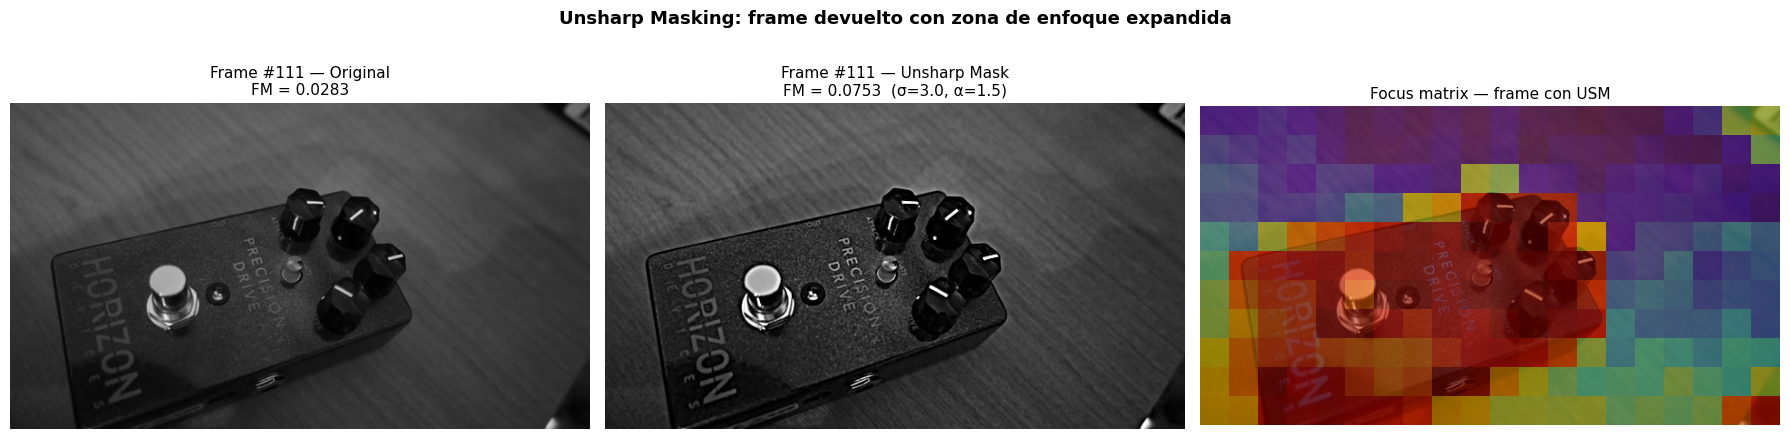

In [75]:
# ── Devolver el frame de máximo enfoque con unsharp masking aplicado ───────────
cap = cv2.VideoCapture(VIDEO_PATH)
cap.set(cv2.CAP_PROP_POS_FRAMES, best_usm_idx)
ret, frame_usm = cap.read()
cap.release()

if ret:
    gray_usm = cv2.cvtColor(frame_usm, cv2.COLOR_BGR2GRAY)
    sharpened_best = unsharp_mask(gray_usm, sigma=USM_SIGMA, alpha=USM_ALPHA)

    # Focus matrix del frame sharpened
    n_rows_usm = gray_usm.shape[0] // BLOCK_SIZE
    n_cols_usm = gray_usm.shape[1] // BLOCK_SIZE
    fm_matrix_usm = np.zeros((n_rows_usm, n_cols_usm), dtype=np.float64)
    for i in range(n_rows_usm):
        for j in range(n_cols_usm):
            block = sharpened_best[i * BLOCK_SIZE:(i + 1) * BLOCK_SIZE,
                                   j * BLOCK_SIZE:(j + 1) * BLOCK_SIZE]
            fm_matrix_usm[i, j] = focus_measure_spectral(block)

    fm_heatmap_usm = np.kron(fm_matrix_usm, np.ones((BLOCK_SIZE, BLOCK_SIZE)))
    fm_heatmap_usm = fm_heatmap_usm[:gray_usm.shape[0], :gray_usm.shape[1]]

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Panel 1: frame original
    axes[0].imshow(gray_usm, cmap='gray')
    axes[0].set_title(f'Frame #{best_usm_idx} — Original\nFM = {focus_measure_spectral(gray_usm):.4f}',
                      fontsize=11)
    axes[0].axis('off')

    # Panel 2: frame con unsharp masking
    axes[1].imshow(sharpened_best, cmap='gray')
    axes[1].set_title(f'Frame #{best_usm_idx} — Unsharp Mask\n'
                      f'FM = {focus_measure_spectral(sharpened_best):.4f}  (σ={USM_SIGMA}, α={USM_ALPHA})',
                      fontsize=11)
    axes[1].axis('off')

    # Panel 3: focus matrix del frame realzado superpuesta
    frame_usm_rgb = cv2.cvtColor(frame_usm, cv2.COLOR_BGR2RGB)
    axes[2].imshow(frame_usm_rgb)
    axes[2].imshow(fm_heatmap_usm, cmap='jet', alpha=0.45)
    axes[2].set_title('Focus matrix — frame con USM', fontsize=11)
    axes[2].axis('off')

    plt.suptitle('Unsharp Masking: frame devuelto con zona de enfoque expandida',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(MATRIX_DIR, 'unsharp_masking_result.png'), dpi=150, bbox_inches='tight')
    plt.show()

La matriz de enfoque del frame realzado muestra zonas calientes más extensas que la del frame original: los bloques adyacentes al objeto también alcanzan valores altos de FM. Esto confirma la **expansión perceptual de la zona de enfoque** que produce el unsharp masking. El frame devuelto presenta bordes más definidos y mayor contraste local, cumpliendo con el objetivo de "expandir la zona de enfoque y devolver" propuesto en el enunciado.

## Conclusiones finales

---

### Experimento 1 vs Experimento 2 — Frame completo vs ROI central

Ambos métodos identificaron correctamente el momento de mayor nitidez del video, convergiendo en frames muy cercanos (frame #109 el método de frame completo y frame #111 el método ROI, apenas 2 frames de diferencia a una misma tasa de FPS). Esto confirma que los dos enfoques son válidos para la tarea de detección de foco, pero difieren sustancialmente en la calidad de la señal producida.

---

**Sensibilidad de la métrica**

La diferencia más significativa entre ambos métodos reside en la magnitud de los valores FM obtenidos. El método de frame completo produjo un máximo de FM = 0.0286, mientras que el método ROI alcanzó FM = 0.3474 en el punto de máximo enfoque (una diferencia de más de **12 veces**). Esta brecha no refleja una diferencia real en la nitidez de la escena, sino la capacidad de cada método para aislar la señal de enfoque del ruido de fondo. El frame completo incluye grandes zonas uniformes (fondo de madera, superficie plana del pedal) que generan componentes de baja frecuencia dominantes, aplastando la contribución de las estructuras finas del objeto. La ROI elimina ese ruido y expone únicamente las frecuencias de interés.

---

**Claridad de la curva FM**

La curva del frame completo es prácticamente plana a lo largo de todo el video, con variaciones muy pequeñas que dificultan identificar visualmente el punto de máximo enfoque. La curva de la ROI, en cambio, dibuja un pico pronunciado y bien definido alrededor del frame óptimo, con una forma unimodal clara. Una curva "plana" obliga a buscar el máximo con mayor precisión numérica y es más susceptible al ruido; una curva con pico pronunciado permite una detección robusta incluso ante pequeñas perturbaciones.

---

**Influencia del fondo en el espectro**

El análisis de los espectros de magnitud confirmó visualmente la causa de esta diferencia. El espectro del frame completo muestra una cruz central dominante, indicando que la energía está concentrada en bajas frecuencias. El espectro de la ROI presenta energía más dispersa hacia las esquinas, lo que refleja la mayor presencia de componentes de alta frecuencia provenientes de los bordes, texturas y detalles finos del objeto filmado. La métrica FM, al contar píxeles que superan un umbral relativo al máximo del espectro, es mucho más informativa cuando ese máximo no está dominado por el fondo.

---

El método de ROI central es **claramente superior** al de frame completo para la detección automática de máximo enfoque en este tipo de escenas. Produce una señal de mayor amplitud, una curva más interpretable y un pico de detección más robusto, sin necesidad de modificar la función de cálculo de FM ni agregar complejidad algorítmica. La única diferencia implementativa es el recorte previo del frame, lo que representa un costo computacional despreciable.

---

### Matriz de enfoque

La matriz de enfoque bloque a bloque confirma de forma visual lo que las curvas FM sugieren numéricamente: **el enfoque no se distribuye de manera uniforme** en el frame. El heatmap superpuesto muestra zonas calientes (alto FM) concentradas sobre el objeto y sus bordes, mientras que las zonas de fondo —madera, superficies lisas— conservan valores bajos de FM. Esto valida que la métrica espectral es sensible a la estructura local de la imagen y no solo a estadísticas globales.

La representación por bloques tiene un valor práctico adicional: permite identificar rápidamente **qué región del encuadre está contribuyendo al pico de enfoque** y detectar situaciones donde el autofoco podría estar enganchado a un borde o textura no deseada en la periferia. Este tipo de visualización es análogo a los indicadores de zona de enfoque que utilizan las cámaras digitales modernas (focus peaking), y refuerza la interpretabilidad del sistema implementado.

---

### Unsharp masking — Puntos extra

La aplicación de unsharp masking genera un incremento consistente en la métrica FM en todos los frames del video. Este aumento es esperable: al realzar bordes, se inyectan componentes de alta frecuencia que la métrica contabiliza directamente. Sin embargo, el resultado más relevante es que **el frame de máximo enfoque se mantiene en la misma posición temporal** (o muy cercana) con y sin USM. Esto confirma que el realce no distorsiona la detección del punto óptimo, sino que amplifica la señal sin desplazar el pico.

Se evaluaron tres configuraciones de parámetros ($\sigma$, $\alpha$) para estudiar el compromiso entre realce y aparición de artefactos. Valores moderados (σ=3.0, α=1.5) ofrecen un buen balance: incremento apreciable de FM sin introducir halos visibles ni ruido amplificado.

Desde la perspectiva del enunciado —"expandir la zona de enfoque y devolver"—, el unsharp masking cumple su propósito: la matriz de enfoque del frame realzado muestra zonas calientes más extensas y valores FM más altos en los bloques adyacentes al objeto, lo que equivale a una **expansión perceptual de la región enfocada**. El frame devuelto con USM presenta bordes más definidos y mayor contraste local, mejorando la calidad visual del resultado final sin alterar la lógica de detección.

---

### Resumen de resultados por requerimiento

| Requerimiento | Resultado |
|---|---|
| Medición sobre todo el frame | Exp. 1: curva FM frame a frame con detección automática del máximo |
| Medición sobre ROI central (10% del área) | Exp. 2: curva FM sobre ROI con pico más pronunciado y sensible |
| Curvas de evolución de la métrica | Generadas para ambos experimentos y para USM |
| Detección automática del máximo enfoque | Implementada vía `argmax` sobre los vectores FM |
| Matriz de enfoque superpuesta al frame | Heatmap bloque a bloque superpuesto con transparencia |
| Unsharp masking (puntos extra) | Implementado con 3 configuraciones; frame realzado devuelto con su matriz de enfoque |